# House Prices

##  Import & nạp dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

train = pd.read_csv('Data/train.csv')
test  = pd.read_csv('Data/test.csv')

train_raw = train.copy()
test_raw  = test.copy()

print('Train:', train.shape, '| Test:', test.shape)

Train: (1460, 81) | Test: (1459, 80)


# House Prices

## 0. Import & nạp dữ liệu

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

train = pd.read_csv('Data/train.csv')
test  = pd.read_csv('Data/test.csv')

train_raw = train.copy()
test_raw  = test.copy()

print('Train:', train.shape, '| Test:', test.shape)

Train: (1460, 81) | Test: (1459, 80)


## 1. Phân loại biến

In [3]:
ID_COL = 'Id'
TARGET = 'SalePrice'

discrete_cols = [
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold',
    'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
]

continuous_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
    'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', TARGET,
]

ordinal_cols = [
    'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual',
    'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'LotShape',
    'LandSlope', 'Utilities', 'Functional', 'GarageFinish', 'PavedDrive',
]

assigned = {ID_COL, *discrete_cols, *continuous_cols, *ordinal_cols}
nominal_cols = [c for c in train.columns if c not in assigned]

groups = {
    'Số – rời rạc': discrete_cols,
    'Số – liên tục': continuous_cols,
    'Phân loại – thứ tự': ordinal_cols,
    'Phân loại – danh nghĩa': nominal_cols,
}

all_assigned = [ID_COL] + discrete_cols + continuous_cols + ordinal_cols + nominal_cols
assert len(all_assigned) == len(set(all_assigned)), 'Có cột bị gán trùng nhóm'
assert set(all_assigned) == set(train.columns), 'Có cột chưa được phân nhóm'

col2group = {ID_COL: 'Định danh (Id)'}
for g, cols in groups.items():
    for c in cols:
        col2group[c] = g

for g, cols in groups.items():
    print(f'\n[{g}] ({len(cols)} cột):\n  ', ', '.join(cols))


[Số – rời rạc] (14 cột):
   YearBuilt, YearRemodAdd, GarageYrBlt, MoSold, YrSold, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, TotRmsAbvGrd, Fireplaces, GarageCars

[Số – liên tục] (20 cột):
   LotFrontage, LotArea, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, GarageArea, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, MiscVal, SalePrice

[Phân loại – thứ tự] (22 cột):
   OverallQual, OverallCond, ExterQual, ExterCond, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, FireplaceQu, GarageQual, GarageCond, PoolQC, Fence, LotShape, LandSlope, Utilities, Functional, GarageFinish, PavedDrive

[Phân loại – danh nghĩa] (24 cột):
   MSSubClass, MSZoning, Street, Alley, LandContour, LotConfig, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, Foundation, Heating, CentralAir, 

## 2. Báo cáo tỷ lệ dữ liệu khuyết

In [4]:
def missing_report(df, name):
    n = len(df)
    rep = pd.DataFrame({'Số dòng khuyết': df.isnull().sum()})
    rep['Tỷ lệ khuyết (%)'] = (rep['Số dòng khuyết'] / n * 100).round(2)
    rep = rep[rep['Số dòng khuyết'] > 0].sort_values('Tỷ lệ khuyết (%)', ascending=False)
    total = df.size
    print(f'[{name}] {len(rep)}/{df.shape[1]} cột có khuyết | '
          f'{int(df.isnull().sum().sum())} ô khuyết ({df.isnull().sum().sum()/total*100:.2f}% tổng số ô)')
    return rep

report_train = missing_report(train_raw, 'TRAIN')

[TRAIN] 19/81 cột có khuyết | 7829 ô khuyết (6.62% tổng số ô)


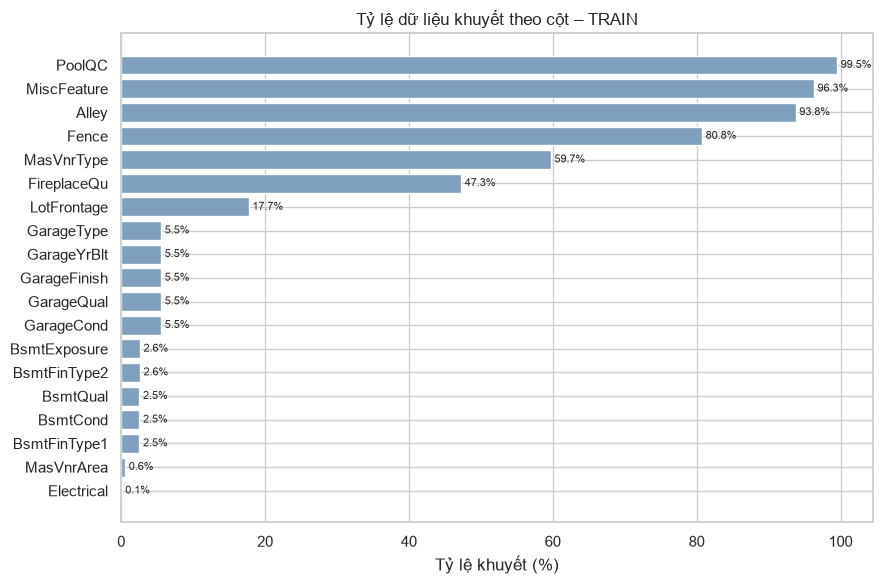

In [5]:
KEY = ['PoolQC', 'Alley', 'Fence', 'FireplaceQu']

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = report_train.reset_index().rename(columns={'index': 'Cột'})
ax.barh(plot_df['Cột'], plot_df['Tỷ lệ khuyết (%)'], color='#7f9fbf')
ax.invert_yaxis()
ax.set_xlabel('Tỷ lệ khuyết (%)')
ax.set_title('Tỷ lệ dữ liệu khuyết theo cột – TRAIN')
for i, v in enumerate(plot_df['Tỷ lệ khuyết (%)']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

In [6]:
report_test = missing_report(test_raw, 'TEST')

[TEST] 33/80 cột có khuyết | 7878 ô khuyết (6.75% tổng số ô)


## 3. Điền khuyết

In [7]:
STRUCTURES = {
    'Hồ bơi': (['PoolQC'], ['PoolArea'],
               lambda d: d['PoolArea'].fillna(0) > 0),
    'Tầng hầm': (['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'],
                 ['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'],
                 lambda d: d['TotalBsmtSF'].fillna(0) > 0),
    'Gara': (['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'],
             ['GarageCars', 'GarageArea', 'GarageYrBlt'],
             lambda d: d['GarageType'].notna() | (d['GarageArea'].fillna(0) > 0)),
    'Lò sưởi': (['FireplaceQu'], [],
                lambda d: d['Fireplaces'].fillna(0) > 0),
    'Ốp gạch/đá': ([], ['MasVnrArea'],
                   lambda d: d['MasVnrArea'].fillna(0) > 0),
    'Tiện ích khác': (['MiscFeature'], [],
                      lambda d: d['MiscVal'].fillna(0) > 0),
}

ALWAYS_NONE = ['Alley', 'Fence', 'MasVnrType']

def fit_fill_values(ref):
    vals = {}
    for name, (cat, num, has) in STRUCTURES.items():
        mask = has(ref)
        for c in cat:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.mode()[0] if len(s) else 'None'
        for c in num:
            s = ref.loc[mask, c].dropna()
            vals[c] = s.median() if len(s) else 0
    return vals

fill_values = fit_fill_values(train_raw)

def impute_structural(df):
    df = df.copy()
    masks = {name: has(df) for name, (_, _, has) in STRUCTURES.items()}
    for name, (cat, num, _) in STRUCTURES.items():
        present = masks[name]
        for c in cat:
            na = df[c].isna()
            df.loc[na & ~present, c] = 'None'
            df.loc[na & present, c] = fill_values[c]
        for c in num:
            na = df[c].isna()
            df.loc[na & ~present, c] = 0
            if c == 'GarageYrBlt':
                df.loc[na & present, c] = df.loc[na & present, 'YearBuilt']
            else:
                df.loc[na & present, c] = fill_values[c]
    for c in ALWAYS_NONE:
        df[c] = df[c].fillna('None')
    return df

train = impute_structural(train)
test = impute_structural(test)

### Khuyết ngẫu nhiên còn lại

In [8]:
RANDOM_CAT = ['Electrical', 'MSZoning', 'Utilities', 'Functional', 'Exterior1st',
              'Exterior2nd', 'KitchenQual', 'SaleType']

for c in RANDOM_CAT:
    mode_val = train_raw[c].mode()[0]
    for d in (train, test):
        d[c] = d[c].fillna(mode_val)

for d, nm in ((train, 'train'), (test, 'test')):
    for c in d.columns:
        if c in ('LotFrontage', TARGET) or not d[c].isna().any():
            continue
        fill = train_raw[c].median() if pd.api.types.is_numeric_dtype(d[c]) else train_raw[c].mode()[0]
        print(f'[safety-net] {nm}.{c}: {d[c].isna().sum()} ô → {fill}')
        d[c] = d[c].fillna(fill)

print('Còn khuyết sau bước này:')
print('  train:', train.drop(columns='LotFrontage').isna().sum().sum(),
      '| test:', test.drop(columns='LotFrontage').isna().sum().sum())

Còn khuyết sau bước này:
  train: 0 | test: 0


## 4. Nội suy LotFrontage theo Neighborhood

In [9]:
lf_median_by_nb = train_raw.groupby('Neighborhood')['LotFrontage'].median()
lf_global_median = train_raw['LotFrontage'].median()

def impute_lotfrontage(df):
    df = df.copy()
    before = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(df['Neighborhood'].map(lf_median_by_nb))
    fallback = int(df['LotFrontage'].isna().sum())
    df['LotFrontage'] = df['LotFrontage'].fillna(lf_global_median)
    print(f'  khuyết ban đầu: {before} | điền theo Neighborhood: {before - fallback} | '
          f'dự phòng bằng median toàn cục: {fallback}')
    return df

print('TRAIN'); train = impute_lotfrontage(train)
print('TEST');  test  = impute_lotfrontage(test)

print(f"\nLotFrontage train – trước: mean={train_raw['LotFrontage'].mean():.2f}, "
      f"median={train_raw['LotFrontage'].median():.2f} | sau: mean={train['LotFrontage'].mean():.2f}, "
      f"median={train['LotFrontage'].median():.2f}")

TRAIN
  khuyết ban đầu: 259 | điền theo Neighborhood: 259 | dự phòng bằng median toàn cục: 0
TEST
  khuyết ban đầu: 227 | điền theo Neighborhood: 227 | dự phòng bằng median toàn cục: 0

LotFrontage train – trước: mean=70.05, median=69.00 | sau: mean=70.20, median=70.00


## 5. Kiểm tra đầu ra

In [10]:
na_train, na_test = int(train.isna().sum().sum()), int(test.isna().sum().sum())
print(f'NaN train: {na_train} | NaN test: {na_test}')
print(f'Shape train: {train.shape} | test: {test.shape}')
assert na_train == 0 and na_test == 0
assert train.shape == train_raw.shape and test.shape == test_raw.shape
assert (train['Id'].values == train_raw['Id'].values).all()

NaN train: 0 | NaN test: 0
Shape train: (1460, 81) | test: (1459, 80)


In [11]:
train.to_csv('Data/train_filled.csv', index=False)
test.to_csv('Data/test_filled.csv', index=False)

chk_tr = pd.read_csv('Data/train_filled.csv', keep_default_na=False, na_values=[''])
chk_te = pd.read_csv('Data/test_filled.csv',  keep_default_na=False, na_values=[''])
print('Nạp lại → NaN train:', chk_tr.isna().sum().sum(), '| NaN test:', chk_te.isna().sum().sum())

Nạp lại → NaN train: 0 | NaN test: 0


## 6. Feature Engineering

In [12]:
train_fe, test_fe = train.copy(), test.copy()

def add_features(d):
    d['TotalSF']      = d['TotalBsmtSF'] + d['1stFlrSF'] + d['2ndFlrSF']
    d['HouseAge']     = d['YrSold'] - d['YearBuilt']
    d['RemodAge']     = d['YrSold'] - d['YearRemodAdd']
    d['TotalBath']    = d['FullBath'] + 0.5 * d['HalfBath'] + d['BsmtFullBath'] + 0.5 * d['BsmtHalfBath']
    d['HasGarage']    = (d['GarageArea'] > 0).astype(int)
    d['HasBsmt']      = (d['TotalBsmtSF'] > 0).astype(int)
    d['HasFireplace'] = (d['Fireplaces'] > 0).astype(int)
    d['Has2ndFloor']  = (d['2ndFlrSF'] > 0).astype(int)
    d['TotalPorchSF'] = (d['OpenPorchSF'] + d['3SsnPorch'] + d['EnclosedPorch']
                         + d['ScreenPorch'] + d['WoodDeckSF'])
    return d

train_fe, test_fe = add_features(train_fe), add_features(test_fe)

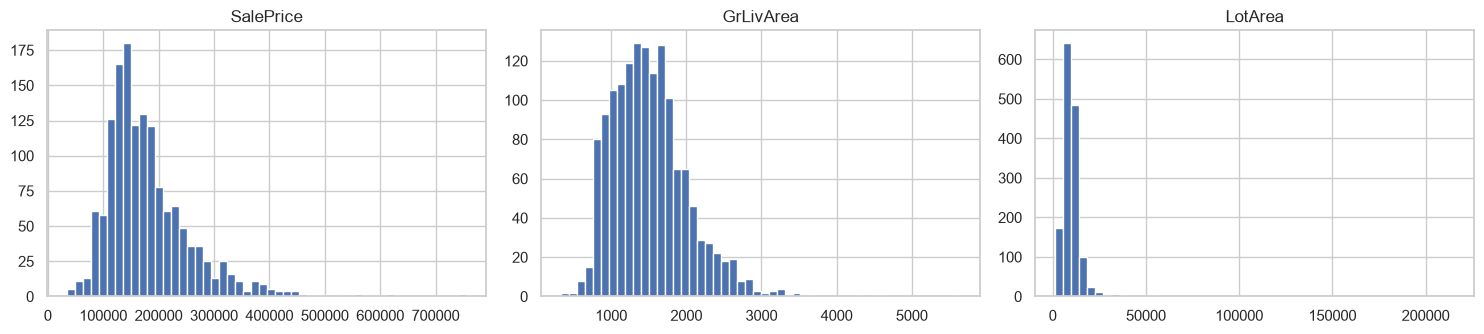

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, col in zip(axes, ['SalePrice', 'GrLivArea', 'LotArea']):
    train_fe[col].hist(bins=50, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

In [14]:
log_features = ['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'BsmtFinSF2',
                'ScreenPorch', 'EnclosedPorch', 'MasVnrArea', 'LotFrontage', 'OpenPorchSF',
                'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'TotalSF']

for col in log_features:
    train_fe[col] = np.log1p(train_fe[col])
    test_fe[col]  = np.log1p(test_fe[col])

In [15]:
print('Cột chỉ có ở train:', set(train_fe.columns) - set(test_fe.columns))
print('Cột chỉ có ở test :', set(test_fe.columns) - set(train_fe.columns))
print('Train shape:', train_fe.shape, '| Test shape:', test_fe.shape)
print('NaN train_fe:', train_fe.isna().sum().sum(), '| NaN test_fe:', test_fe.isna().sum().sum())
assert train_fe.isna().sum().sum() == 0 and test_fe.isna().sum().sum() == 0

train_fe.to_csv('Data/train_fe.csv', index=False)
test_fe.to_csv('Data/test_fe.csv', index=False)

Cột chỉ có ở train: {'SalePrice'}
Cột chỉ có ở test : set()
Train shape: (1460, 90) | Test shape: (1459, 89)
NaN train_fe: 0 | NaN test_fe: 0


## 7. Chuẩn bị phân tích đa biến

In [16]:
import warnings
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

CORR_THRESHOLD = 0.7
VIF_THRESHOLD = 5

# Dùng lại cách phân nhóm ở mục 1. OverallQual/OverallCond thuộc nhóm thứ tự
# nhưng lưu dạng số 1–10 nên vẫn đưa vào tương quan Pearson.
num_cols = [c for c in discrete_cols + continuous_cols + ordinal_cols
            if pd.api.types.is_numeric_dtype(train[c])]
feat_cols = [c for c in num_cols if c != TARGET]
cat_cols = [c for c in ordinal_cols + nominal_cols if c not in num_cols]

print(f'Biến số độc lập: {len(feat_cols)} | biến phân loại: {len(cat_cols)} | target: {TARGET}')
assert not set(num_cols) & set(cat_cols), 'Có cột nằm ở cả hai nhóm'
assert set(num_cols) | set(cat_cols) | {ID_COL} == set(train.columns), 'Có cột chưa được phân nhóm'

Biến số độc lập: 35 | biến phân loại: 44 | target: SalePrice


## 8. Tương quan Pearson với SalePrice

In [17]:
corr_target = train[num_cols].corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print(corr_target.head(10).round(3).to_string())

OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507


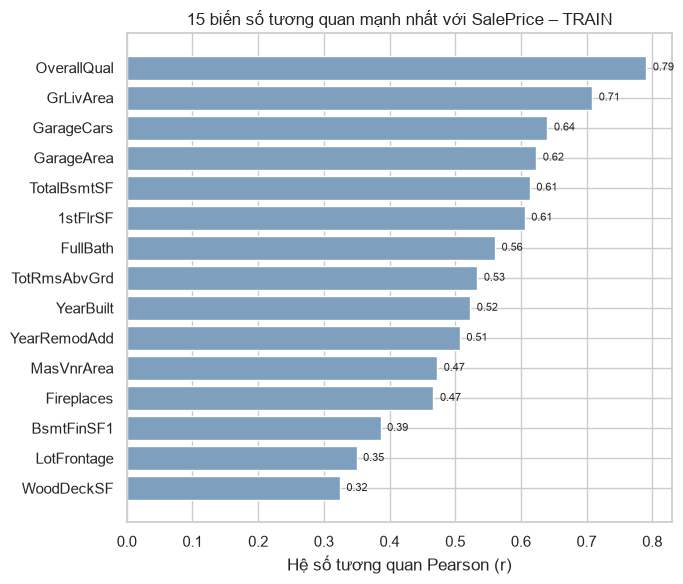

In [18]:
top = corr_target.head(15)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top.index, top.values, color='#7f9fbf')
ax.invert_yaxis()
ax.set_xlabel('Hệ số tương quan Pearson (r)')
ax.set_title('15 biến số tương quan mạnh nhất với SalePrice – TRAIN')
for i, v in enumerate(top.values):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

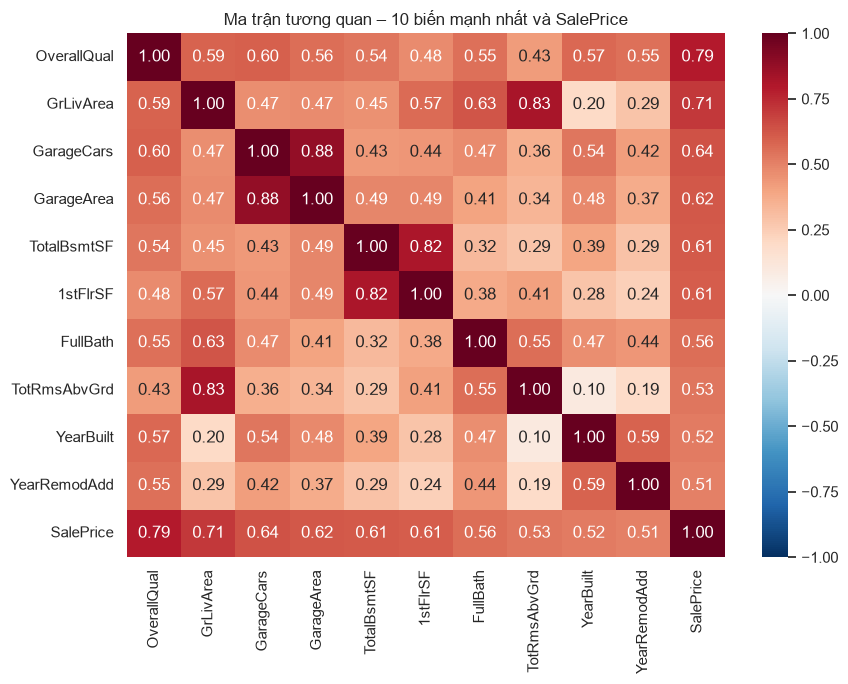

In [19]:
top10 = corr_target.head(10).index.tolist() + [TARGET]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(train[top10].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Ma trận tương quan – 10 biến mạnh nhất và SalePrice')
plt.tight_layout(); plt.show()

`OverallQual` có tương quan mạnh nhất với `SalePrice` (r ≈ 0.79). Tiếp theo là các biến về diện tích và gara: `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62) và `TotalBsmtSF` (0.61). Như vậy giá nhà chủ yếu phụ thuộc vào chất lượng hoàn thiện và không gian sử dụng. Trên heatmap cũng thấy nhiều ô đậm giữa chính các biến độc lập (gara, tầng hầm, diện tích sống), đây là dấu hiệu đa cộng tuyến sẽ được kiểm tra ở mục 9 và mục 11.

## 9. Cặp biến độc lập tương quan chặt

In [20]:
corr_feat = train[feat_cols].corr()
iu = np.triu_indices_from(corr_feat, k=1)
pairs = pd.DataFrame({'Biến 1': corr_feat.columns[iu[0]],
                      'Biến 2': corr_feat.columns[iu[1]],
                      'r': corr_feat.values[iu]})
strong_pairs = (pairs[pairs['r'].abs() > CORR_THRESHOLD]
                .sort_values('r', key=abs, ascending=False).reset_index(drop=True))

print(f'{len(strong_pairs)} cặp có |r| > {CORR_THRESHOLD}:')
print(strong_pairs.round(3).to_string())

3 cặp có |r| > 0.7:
         Biến 1      Biến 2      r
0    GarageCars  GarageArea  0.882
1  TotRmsAbvGrd   GrLivArea  0.825
2   TotalBsmtSF    1stFlrSF  0.820


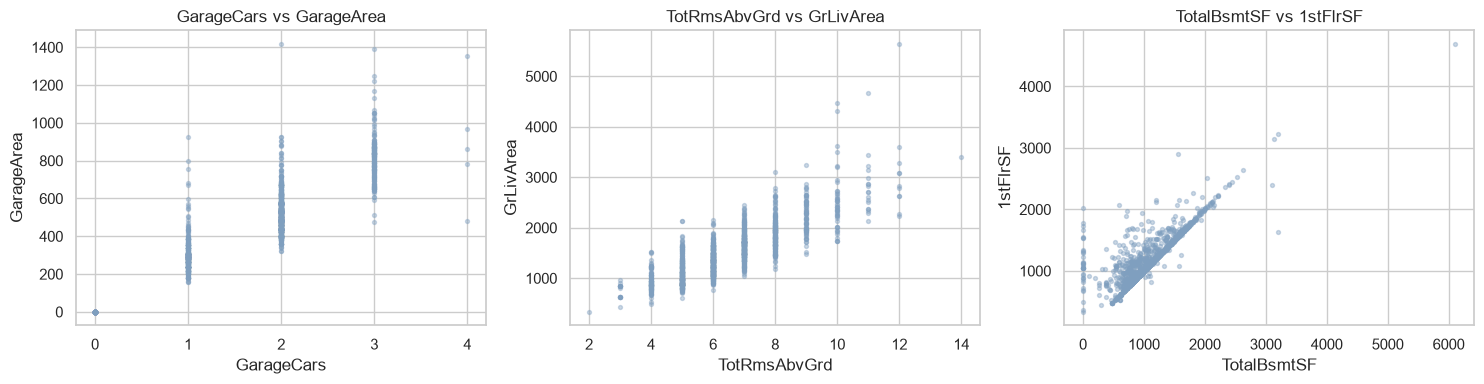

In [21]:
fig, axes = plt.subplots(1, len(strong_pairs), figsize=(5 * len(strong_pairs), 4))
for ax, (a, b) in zip(np.atleast_1d(axes), strong_pairs[['Biến 1', 'Biến 2']].values):
    ax.scatter(train[a], train[b], s=8, alpha=0.4, color='#7f9fbf')
    ax.set_xlabel(a); ax.set_ylabel(b); ax.set_title(f'{a} vs {b}')
plt.tight_layout(); plt.show()

Có 3 cặp biến độc lập có |r| > 0.7: `GarageCars` & `GarageArea` (0.88), `GrLivArea` & `TotRmsAbvGrd` (0.83) và `TotalBsmtSF` & `1stFlrSF` (0.82). Cả ba cặp đều có lời giải thích thực tế: sức chứa gara do diện tích gara quyết định, nhà có nhiều phòng hơn thì diện tích sống lớn hơn, và móng tầng một nằm ngay trên tầng hầm. Mỗi cặp mang thông tin gần như trùng nhau nên chỉ cần giữ một biến.

## 10. Biến phân loại: ANOVA và boxplot

In [22]:
y_log = np.log1p(train[TARGET])

def anova_report(cols):
    rows = []
    for c in cols:
        grp = [y_log[idx].values for idx in train.groupby(c).groups.values() if len(idx) > 1]
        if len(grp) < 2:
            continue
        F, p = stats.f_oneway(*grp)
        ssb = sum(len(g) * (g.mean() - y_log.mean()) ** 2 for g in grp)
        rows.append((c, F, p, ssb / ((y_log - y_log.mean()) ** 2).sum()))
    return (pd.DataFrame(rows, columns=['Biến', 'F', 'p-value', 'eta²'])
            .sort_values('eta²', ascending=False).reset_index(drop=True))

anova = anova_report(cat_cols)
print(anova.head(10).round(4).to_string())

           Biến         F  p-value    eta²
0  Neighborhood   79.5205      0.0  0.5708
1     ExterQual  415.3043      0.0  0.4611
2      BsmtQual  300.3929      0.0  0.4523
3   KitchenQual  393.3209      0.0  0.4476
4  GarageFinish  298.7696      0.0  0.3810
5    GarageType  121.7962      0.0  0.3346
6    MSSubClass   50.8661      0.0  0.3301
7   FireplaceQu  131.1986      0.0  0.3109
8    Foundation  126.8068      0.0  0.3037
9     HeatingQC  146.6100      0.0  0.2317


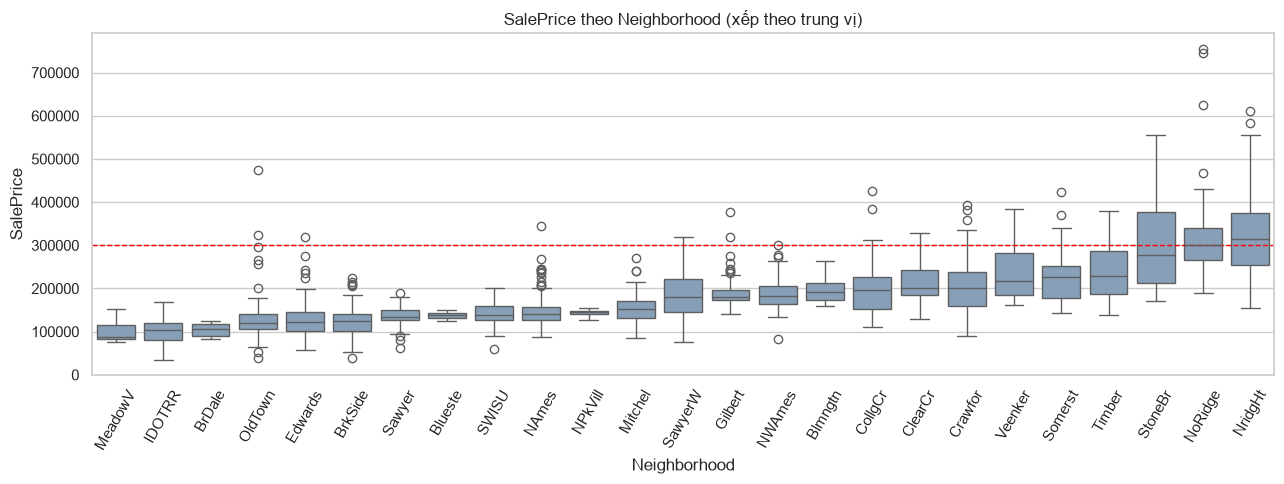

Rẻ nhất : {'MeadowV': 88000.0, 'IDOTRR': 103000.0, 'BrDale': 106000.0}
Đắt nhất: {'StoneBr': 278000.0, 'NoRidge': 301500.0, 'NridgHt': 315000.0}
Độ lệch chuẩn StoneBr = 112970 | MeadowV = 23491


In [23]:
nb_median = train.groupby('Neighborhood')[TARGET].median().sort_values()
nb_std = train.groupby('Neighborhood')[TARGET].std()

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=train, x='Neighborhood', y=TARGET, order=nb_median.index,
            color='#7f9fbf', ax=ax)
ax.axhline(300000, ls='--', color='red', lw=1)
ax.tick_params(axis='x', rotation=60)
ax.set_title('SalePrice theo Neighborhood (xếp theo trung vị)')
plt.tight_layout(); plt.show()

print('Rẻ nhất :', nb_median.head(3).round(0).to_dict())
print('Đắt nhất:', nb_median.tail(3).round(0).to_dict())
print(f"Độ lệch chuẩn StoneBr = {nb_std['StoneBr']:.0f} | MeadowV = {nb_std['MeadowV']:.0f}")

ANOVA kiểm định xem giá trung bình (đã log hóa) có khác nhau giữa các nhóm của một biến hay không, còn eta² cho biết biến đó giải thích bao nhiêu phần phương sai của giá. Tất cả các biến đầu bảng đều có p-value xấp xỉ 0. `Neighborhood` cao nhất (eta² ≈ 0.57), nghĩa là vị trí một mình giải thích hơn một nửa phương sai của log giá. Tiếp theo là `ExterQual`, `BsmtQual`, `KitchenQual` (cùng khoảng 0.45), đều là các biến chất lượng. Boxplot cho thấy `MeadowV` rẻ nhất (trung vị 88,000 USD) còn `StoneBr`, `NoRidge`, `NridgHt` đắt nhất (278,000 đến 315,000 USD). Độ lệch chuẩn của `StoneBr` (khoảng 113,000 USD) lớn hơn nhiều so với `MeadowV` (khoảng 23,000 USD), tức là khu càng đắt thì giá càng phân tán.

## 11. Chẩn đoán đa cộng tuyến (VIF)

In [24]:
def vif_table(X):
    # Biến nằm trong quan hệ tuyến tính chính xác (cộng tuyến hoàn hảo) → VIF = vô hạn.
    # Xác định bằng SVD: hướng có giá trị suy biến ≈ 0 là các tổ hợp cho ra đúng 0.
    Z = (X - X.mean()) / X.std()
    _, s, vt = np.linalg.svd(Z.values, full_matrices=False)
    null_dirs = vt[s < 1e-8 * s[0]]
    exact = list(X.columns[np.abs(null_dirs).max(axis=0) > 1e-6]) if len(null_dirs) else []

    Xc = X.assign(const=1.0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        vals = [variance_inflation_factor(Xc.values, i) for i in range(X.shape[1])]
    vif = pd.Series(vals, index=X.columns, name='VIF')
    vif[exact] = np.inf
    return vif.sort_values(ascending=False)

vif_before = vif_table(train[feat_cols])
print(f'Số biến có VIF > {VIF_THRESHOLD}: {int((vif_before > VIF_THRESHOLD).sum())}')
print(vif_before.head(12).map(lambda v: f'{v:,.3g}').to_string())

Số biến có VIF > 5: 10
GrLivArea        inf
BsmtFinSF1       inf
BsmtFinSF2       inf
2ndFlrSF         inf
1stFlrSF         inf
TotalBsmtSF      inf
LowQualFinSF     inf
BsmtUnfSF        inf
GarageCars      6.07
GarageArea      5.32
TotRmsAbvGrd    4.83
YearBuilt        4.1


In [25]:
# VIF vô hạn là cộng tuyến hoàn hảo: mỗi biến tổng bằng đúng tổng các thành phần
bsmt_gap = (train['TotalBsmtSF'] - train[['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF']].sum(axis=1)).abs().max()
liv_gap  = (train['GrLivArea'] - train[['1stFlrSF', '2ndFlrSF', 'LowQualFinSF']].sum(axis=1)).abs().max()
print(f'TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF → sai lệch lớn nhất: {bsmt_gap}')
print(f'GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF  → sai lệch lớn nhất: {liv_gap}')
assert bsmt_gap < 1e-9 and liv_gap < 1e-9, 'Đẳng thức tổng không còn đúng'

TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF → sai lệch lớn nhất: 0
GrLivArea   = 1stFlrSF + 2ndFlrSF + LowQualFinSF  → sai lệch lớn nhất: 0


Lần chạy VIF đầu tiên cho thấy 8 biến có VIF vô hạn (hiển thị `inf`). Đây là cộng tuyến hoàn hảo chứ không phải tương quan mạnh thông thường. Nguyên nhân là hai đẳng thức đúng tuyệt đối trên toàn bộ dữ liệu: `TotalBsmtSF` bằng tổng `BsmtFinSF1`, `BsmtFinSF2`, `BsmtUnfSF`, và `GrLivArea` bằng tổng `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`. Khi đó ma trận thiết kế của hồi quy tuyến tính bị suy biến và hệ số không xác định duy nhất. Ngoài ra `GarageCars` (6.07) và `GarageArea` (5.32) cũng vượt ngưỡng 5.

## 12. Loại biến dư thừa

In [26]:
DROP_FEATURES = {
    'BsmtFinSF1':   'Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)',
    'BsmtFinSF2':   'Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)',
    'BsmtUnfSF':    'Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)',
    '1stFlrSF':     'Thành phần của GrLivArea (cộng tuyến hoàn hảo); r = 0.82 với TotalBsmtSF',
    '2ndFlrSF':     'Thành phần của GrLivArea (cộng tuyến hoàn hảo)',
    'LowQualFinSF': 'Thành phần của GrLivArea (cộng tuyến hoàn hảo)',
    'GarageArea':   'Giữ GarageCars (r với giá cao hơn); r = 0.88 với GarageCars',
    'TotRmsAbvGrd': 'Giữ GrLivArea (r với giá cao hơn); r = 0.83 với GrLivArea',
}
assert set(DROP_FEATURES) <= set(feat_cols), 'Có biến cần loại không nằm trong nhóm biến số'

drop_df = pd.DataFrame({'Biến loại': list(DROP_FEATURES), 'Lý do': list(DROP_FEATURES.values())})
drop_df['r với SalePrice'] = drop_df['Biến loại'].map(corr_target).round(3)
print(drop_df.to_string(index=False))

   Biến loại                                                                    Lý do  r với SalePrice
  BsmtFinSF1                         Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)            0.386
  BsmtFinSF2                         Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)           -0.011
   BsmtUnfSF                         Thành phần của TotalBsmtSF (cộng tuyến hoàn hảo)            0.214
    1stFlrSF Thành phần của GrLivArea (cộng tuyến hoàn hảo); r = 0.82 với TotalBsmtSF            0.606
    2ndFlrSF                           Thành phần của GrLivArea (cộng tuyến hoàn hảo)            0.319
LowQualFinSF                           Thành phần của GrLivArea (cộng tuyến hoàn hảo)           -0.026
  GarageArea              Giữ GarageCars (r với giá cao hơn); r = 0.88 với GarageCars            0.623
TotRmsAbvGrd                Giữ GrLivArea (r với giá cao hơn); r = 0.83 với GrLivArea            0.534


In [27]:
feat_clean = [c for c in feat_cols if c not in DROP_FEATURES]
vif_after = vif_table(train[feat_clean])

print(f'Còn lại {len(feat_clean)} biến | VIF lớn nhất: {vif_after.iloc[0]:.2f} ({vif_after.index[0]})')
print(vif_after.head(10).round(2).to_string())
assert vif_after.max() < VIF_THRESHOLD, 'Vẫn còn biến có VIF vượt ngưỡng'

Còn lại 27 biến | VIF lớn nhất: 4.94 (GrLivArea)
GrLivArea       4.94
YearBuilt       3.99
OverallQual     3.14
GarageCars      2.91
FullBath        2.87
YearRemodAdd    2.23
TotalBsmtSF     2.20
HalfBath        1.77
GarageYrBlt     1.76
BedroomAbvGr    1.73


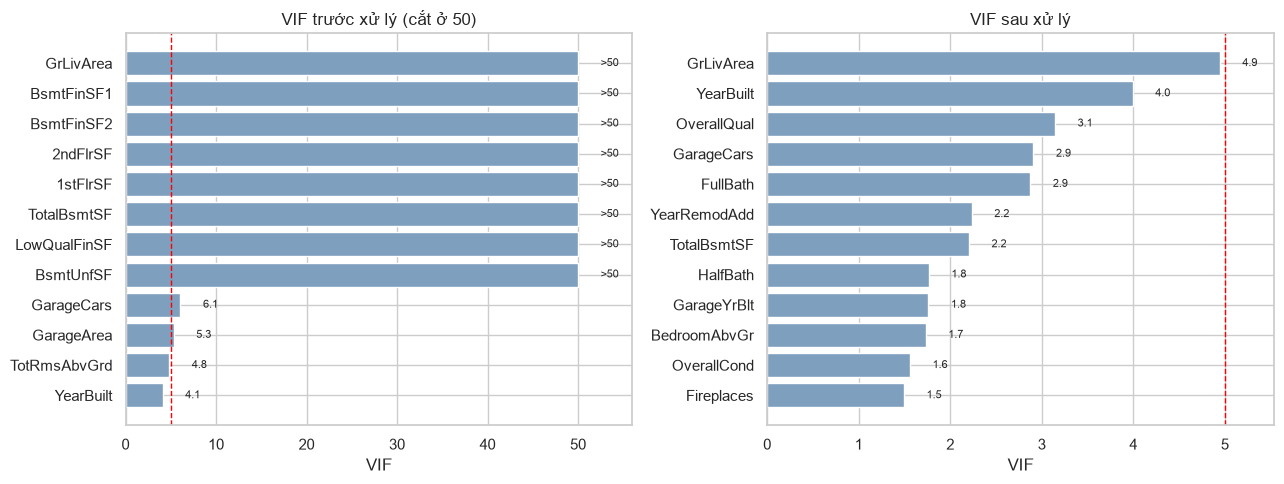

In [28]:
VIF_CAP = 50
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, s, title, cap in ((axes[0], vif_before.head(12), 'VIF trước xử lý (cắt ở 50)', VIF_CAP),
                          (axes[1], vif_after.head(12), 'VIF sau xử lý', None)):
    vals = s.clip(upper=cap) if cap else s
    ax.barh(s.index, vals.values, color='#7f9fbf')
    ax.invert_yaxis()
    ax.axvline(VIF_THRESHOLD, ls='--', color='red', lw=1)
    ax.set_xlabel('VIF'); ax.set_title(title)
    ax.set_xlim(0, vals.max() * 1.12)
    for i, (raw, v) in enumerate(zip(s.values, vals.values)):
        ax.text(v + 0.01 * max(vals.max(), 1) * 5, i, f'>{cap}' if cap and raw > cap else f'{raw:.1f}', va='center', fontsize=8)
plt.tight_layout(); plt.show()

Cách xử lý gồm ba bước, mỗi bước đều có lý do:
1. Giữ hai biến tổng `TotalBsmtSF` và `GrLivArea`, loại 6 biến thành phần. Việc này cũng giải quyết luôn cặp `TotalBsmtSF` & `1stFlrSF`.
2. Giữ `GarageCars`, loại `GarageArea`, vì `GarageCars` tương quan với giá cao hơn (0.64 so với 0.62).
3. Giữ `GrLivArea`, loại `TotRmsAbvGrd`, vì `GrLivArea` tương quan với giá cao hơn nhiều (0.71 so với 0.53).

Sau khi loại 8 biến, còn 27 biến số và VIF lớn nhất là 4.94 (`GrLivArea`), tức mọi biến đều dưới ngưỡng 5. Lưu ý `GrLivArea` sát ngưỡng nên cần theo dõi nếu thêm biến mới.

## 13. Kiểm tra đầu ra

In [29]:
train_reduced = train.drop(columns=list(DROP_FEATURES))
test_reduced  = test.drop(columns=list(DROP_FEATURES))

print(f'Shape train: {train.shape} → {train_reduced.shape} | test: {test.shape} → {test_reduced.shape}')
assert train_reduced.shape == (train.shape[0], train.shape[1] - len(DROP_FEATURES))
assert test_reduced.shape  == (test.shape[0],  test.shape[1]  - len(DROP_FEATURES))
assert not set(DROP_FEATURES) & set(train_reduced.columns), 'Vẫn còn biến cần loại'
assert list(test_reduced.columns) == [c for c in train_reduced.columns if c != TARGET], 'Cột train và test không khớp'
assert train_reduced.isna().sum().sum() == 0 and test_reduced.isna().sum().sum() == 0
assert (train_reduced[ID_COL].values == train[ID_COL].values).all()

Shape train: (1460, 81) → (1460, 73) | test: (1459, 80) → (1459, 72)


In [30]:
train_reduced.to_csv('Data/train_reduced.csv', index=False)
test_reduced.to_csv('Data/test_reduced.csv', index=False)
vif_before.to_csv('Data/vif_before.csv')
vif_after.to_csv('Data/vif_after.csv')
drop_df.to_csv('Data/features_to_drop.csv', index=False)

chk_tr = pd.read_csv('Data/train_reduced.csv', keep_default_na=False, na_values=[''])
chk_te = pd.read_csv('Data/test_reduced.csv',  keep_default_na=False, na_values=[''])
print('Nạp lại → NaN train:', chk_tr.isna().sum().sum(), '| NaN test:', chk_te.isna().sum().sum())

Nạp lại → NaN train: 0 | NaN test: 0


**Kết luận.** Chất lượng tổng thể, diện tích sống và gara là các yếu tố mạnh nhất với giá, còn vị trí (`Neighborhood`) là biến phân loại có ảnh hưởng lớn nhất. Dữ liệu có hai loại đa cộng tuyến: cộng tuyến hoàn hảo do các biến diện tích gốc là thành phần của biến tổng (6 biến), và ba cặp biến song sinh có tương quan từ 0.82 đến 0.88. Sau khi loại 8 biến, bộ dữ liệu giảm còn 73 cột ở tập train và 72 cột ở tập test, rồi được lưu thành `train_reduced.csv` và `test_reduced.csv`. Cần lưu ý Pearson và VIF chỉ đo quan hệ tuyến tính, và việc loại biến chủ yếu có ích cho mô hình tuyến tính như Ridge và Lasso. Mô hình cây như XGBoost và LightGBM ít nhạy với đa cộng tuyến.